In [3]:
!pip install upgrade fused

ERROR: Could not find a version that satisfies the requirement upgrade (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
ERROR: No matching distribution found for upgrade


In [1]:
#!/usr/bin/env python
# coding: utf-8
# Sentinel-2  ➜  Cropland Data Layer (10-class)  —  Inference Notebook
# Author: Gabriel Durkin, 2025-06-22

# ──────────────────────────────────────────────────────────────────────
# 0. SET-UP
# ──────────────────────────────────────────────────────────────────────
#!pip install --upgrade fused  
import fused, torch, random, cv2, gc, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torchvision.transforms.v2 as v2
from torchvision.transforms import InterpolationMode
from transformers import (
    Mask2FormerForUniversalSegmentation,
    Mask2FormerImageProcessor,
)
from torch.utils.data import DataLoader
from datasets import load_dataset, concatenate_datasets

fused._env("prod"); fused.options.show.show_widget = False; fused.options.request_timeout = 180
my_fused_email = "xxx@fused.io"


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/scholtbolt/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/scholtbolt/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/scholtbolt/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io

ModuleNotFoundError: No module named 'cv2'

In [2]:
cdl_simple_map = {0: 0,
 1: 3,
 2: 6,
 3: 6,
 4: 6,
 5: 4,
 6: 6,
 10: 6,
 11: 6,
 12: 3,
 13: 3,
 14: 6,
 21: 6,
 22: 5,
 23: 5,
 24: 5,
 25: 6,
 26: 6,
 27: 6,
 28: 6,
 29: 6,
 30: 6,
 31: 6,
 32: 6,
 33: 6,
 34: 6,
 35: 6,
 36: 6,
 37: 6,
 38: 6,
 39: 6,
 41: 6,
 42: 6,
 43: 6,
 44: 6,
 45: 6,
 46: 6,
 47: 6,
 48: 6,
 49: 6,
 50: 6,
 51: 6,
 52: 6,
 53: 6,
 54: 6,
 55: 6,
 56: 6,
 57: 6,
 58: 8,
 59: 8,
 60: 8,
 61: 8,
 63: 7,
 64: 8,
 65: 9,
 66: 6,
 67: 6,
 68: 6,
 69: 6,
 70: 6,
 71: 6,
 72: 6,
 74: 6,
 75: 6,
 76: 6,
 77: 6,
 81: 0,
 82: 2,
 83: 1,
 87: 7,
 88: 0,
 92: 1,
 111: 1,
 112: 0,
 121: 2,
 122: 2,
 123: 2,
 124: 2,
 131: 9,
 141: 7,
 142: 7,
 143: 7,
 152: 8,
 176: 8,
 190: 7,
 195: 7,
 204: 6,
 205: 5,
 206: 6,
 207: 6,
 208: 6,
 209: 6,
 210: 6,
 211: 6,
 212: 6,
 213: 6,
 214: 6,
 215: 6,
 216: 6,
 217: 6,
 218: 6,
 219: 6,
 220: 6,
 221: 6,
 222: 6,
 223: 6,
 224: 6,
 225: 3,
 226: 3,
 227: 6,
 228: 3,
 229: 6,
 230: 6,
 231: 6,
 232: 6,
 233: 6,
 234: 6,
 235: 6,
 236: 6,
 237: 3,
 238: 6,
 239: 6,
 240: 6,
 241: 6,
 242: 6,
 243: 6,
 244: 6,
 245: 6,
 246: 6,
 247: 6,
 248: 6,
 249: 6,
 250: 6,
 254: 6}

In [3]:
# ──────────────────────────────────────────────────────────────────────
# 1. DEVICE
# ──────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("→  running on:", device)

→  running on: mps


In [4]:
# ──────────────────────────────────────────────────────────────────────
# 2. LABEL DICTIONARIES
# ──────────────────────────────────────────────────────────────────────
id2label = {
    0: "background",
    1: "water",
    2: "developed",
    3: "corn",
    4: "soybeans",
    5: "wheat",
    6: "other agriculture",
    7: "forest/wetlands",
    8: "open lands",
    9: "barren",
}
label2id = {v: k for k, v in id2label.items()}
num_labels = len(id2label)

# Pick whatever colour palette you fancy – here’s a quick, distinctive one
class_colors = {
    "background":        "#000000",  # black
    "water":             "#2f6df6",  # clear blue
    "developed":         "#888888",  # neutral grey
    "corn":              "#ffeb3b",  # strong yellow
    "soybeans":          "#4caf50",  # healthy green
    "wheat":             "#a0522d",  # earthy brown
    "other agriculture": "#9c27b0",  # royal purple
    "forest/wetlands":  "#556B2F",  # Olve Green
    "open lands":        "#ff9800",  # dry orange
    "barren":            "#f5f5dc",  # cream (classic beige)
}

id2color = {label2id[k]: tuple(int(class_colors[k][i + 1 : i + 3], 16) for i in (0, 2, 4)) for k in class_colors}

def vec_translate(arr_2d, mapping):
    """
    2-D label map → 3-D uint8 RGB image (H,W,3).
    Much faster than np.vectorize for large rasters.
    """
    lut = np.array([mapping[k] for k in range(len(mapping))], dtype=np.uint8)  # (num_labels,3)
    return lut[arr_2d]   

In [5]:
# ──────────────────────────────────────────────────────────────────────
# 3. DATASET 

ds = load_dataset("gdurkin/iowa_hyper_jun_24", verification_mode="no_checks")
ds_merged = concatenate_datasets([ds[k] for k in ds.keys()])
ds_split = ds_merged.train_test_split(test_size=0.1, seed=42)
dataset_test = ds_split["test"]

# Minimal “identity” transform: convert uint8→float32 in [0,1]
to_tensor = v2.Compose([v2.ToPILImage(), v2.PILToTensor(), v2.ToDtype(torch.float32, scale=True)])
                                                                     
# ──────────────────────────────────────────────────────────────────────
# 3b.  Validation pre-processor  (remaps raw CDL → 0-9 superclass IDs)
# ──────────────────────────────────────────────────────────────────────
def cdl_to_super(arr_uint16):
    return np.vectorize(cdl_simple_map.__getitem__)(arr_uint16).astype(np.uint8)

def prep_val(batch):
    imgs   = [to_tensor(x) for x in batch["pixel_values"]]
    labels = [torch.as_tensor(cdl_to_super(y)) for y in batch["labels"]]
    return {"pixel_values": imgs, "labels": labels}

dataset_test.set_transform(prep_val)


Using the latest cached version of the dataset since gdurkin/iowa_hyper_jun_24 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/gabriela.durkin/.cache/huggingface/datasets/gdurkin___iowa_hyper_jun_24/default/0.0.0/7862de8182d2fa04af0154c7c90f24c7b92e41df (last modified on Thu Jun 19 10:43:38 2025).
Parameter 'transform'=<function prep_val at 0x292c77f60> of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


In [6]:
# ──────────────────────────────────────────────────────────────────────
# 4. LOAD FINE-TUNED MODEL
# ──────────────────────────────────────────────────────────────────────
model_ckpt = "gdurkin/iowa_corn"  
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    model_ckpt,
    id2label=id2label,
    label2id=label2id,
    num_labels=num_labels,
    ignore_mismatched_sizes=True,
).to(device)

processor = Mask2FormerImageProcessor(
    ignore_index=0, reduce_labels=False, do_resize=False, do_rescale=False, do_normalize=False
)

/Users/gabriela.durkin/miniforge3/envs/aienv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/gabriela.durkin/miniforge3/envs/aienv/lib/python3.11/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [81]:
# ──────────────────────────────────────────────────────────────────────
# 5. SINGLE-IMAGE PREDICTOR
# ──────────────────────────────────────────────────────────────────────
@torch.inference_mode()
def mf_predict(img):
    """
    img : PIL | ndarray (H,W,3 uint8) | tensor (3,H,W) in either [0,255] uint8
          or [0,1] float32
    returns np.uint8 (H,W) class-id map
    """
    # -------- convert to CHW torch tensor, untouch values ----------
    if isinstance(img, np.ndarray):          # HWC uint8
        if img.ndim == 3:
            img = torch.from_numpy(img).permute(2,0,1)
    elif not torch.is_tensor(img):           # PIL
        img = v2.PILToTensor()(img)          # uint8
    # tensor → float32
    if img.dtype != torch.float32:
        img = img.float()
    # -------- ONE-TIME scale to [0,1] if necessary -----------------
    if img.max() > 1.1:          # means it is still 0-255
        img.div_(255.0)
    img = img.unsqueeze(0).to(device)

    model.eval()
    with torch.autocast(device.type):
        out = model(img)

    H, W = img.shape[-2:]
    seg = processor.post_process_semantic_segmentation(
              out, target_sizes=[(H, W)]
          )[0]
    return seg.cpu().numpy()



In [82]:
# ───────────────────────────────────────────────────────────────────────
# Robust tiler  —  predict on arbitrarily large rasters with context
# ───────────────────────────────────────────────────────────────────────
#
# • Handles    PIL • np.ndarray (H,W,3 uint8) • torch tensor (3,H,W,uint8/float)
# • Converts   to uint8 0-255, rescales inside mf_predict() to 0-1.
# • Guarantees every core tile (d_inner²) is predicted with at least
#   ⌊(d_outer-d_inner)/2⌋ pixels of context on all sides; if that margin
#   would fall off the edge it mirror-pads the patch instead of shrinking
#   the context (this keeps accuracy at borders).
# • Works on CPU or GPU.  Autocasts inside mf_predict().
# • Returns a single stitched np.uint8 array of class-ids  (H,W).

from PIL import Image
import numpy as np, torch, gc

def tile_and_predict_with_buffer(img_in,
                                 d_inner: int = 240,
                                 d_outer: int = 960):
    """
    Predict a semantic map for an arbitrarily large RGB image using
    sliding tiles.  Each prediction for the core d_inner×d_inner area
    is made on a surrounding d_outer×d_outer patch to preserve context.

    Parameters
    ----------
    img_in   : PIL.Image | np.ndarray(H,W,3) | torch.Tensor(3,H,W)
               8-bit RGB image.
    d_inner  : int   side length of the ‘core’ tile that is stitched.
    d_outer  : int   side length of the larger patch fed to the model.
                     Must satisfy d_outer >= d_inner and be divisible
                     by d_inner (the stride).

    Returns
    -------
    stitched : np.ndarray of uint8, shape (H, W)
               class-id map for the whole scene.
    """

    # 0 ── normalise input to uint8 HWC array ──────────────────────────
    if torch.is_tensor(img_in):
        arr = img_in.detach().cpu()
        if arr.ndim == 3:         # (3,H,W) or (H,W,3)
            if arr.shape[0] == 3:     # CHW → HWC
                arr = arr.permute(1,2,0)
        arr = arr.numpy()
    elif isinstance(img_in, Image.Image):
        arr = np.asarray(img_in)
    else:
        arr = img_in                    # assume ndarray

    if arr.dtype != np.uint8:
        arr = np.clip(arr,0,255).astype(np.uint8)

    pil_img = Image.fromarray(arr)

    # 1 ── crop to whole-tile multiples (simplest) ─────────────────────
    W_raw, H_raw = pil_img.size
    W = (W_raw // d_inner) * d_inner
    H = (H_raw // d_inner) * d_inner
    pil_img = pil_img.crop((0,0,W,H))

    # 2 ── allocate output canvas ──────────────────────────────────────
    stitched = np.zeros((H, W), dtype=np.uint8)

    stride = d_inner
    margin = (d_outer - d_inner) // 2
    assert margin >= 0, "Require d_outer >= d_inner"

    # 3 ── iterate over core tiles ─────────────────────────────────────
    for top in range(0, H, stride):
        for left in range(0, W, stride):

            # desired patch bounds in full image coords
            t0 = top  - margin
            l0 = left - margin
            t1 = top  + d_inner + margin
            l1 = left + d_inner + margin

            # amount we fall outside, for padding
            pad_top  = max(0, -t0)
            pad_left = max(0, -l0)
            pad_bot  = max(0,  t1 - H)
            pad_right= max(0,  l1 - W)

            # clamp interior bounds for cropping
            ct0, cl0 = max(0, t0), max(0, l0)
            ct1, cl1 = min(H, t1), min(W, l1)

            patch = pil_img.crop((cl0, ct0, cl1, ct1))

            if pad_top or pad_left or pad_bot or pad_right:
                # mirror-pad to reach d_outer size
                patch = np.pad(np.asarray(patch),
                               ((pad_top,pad_bot),
                                (pad_left,pad_right),
                                (0,0)),
                               mode="reflect")
                patch = Image.fromarray(patch)

            # 4 ── predict on the patch ──────────────────────────────
            pred = mf_predict(patch)          # (d_outer,d_outer)

            # 5 ── copy only the central d_inner² area into canvas ───
            row0 = margin
            col0 = margin
            stitched[top : top + d_inner,
                     left: left + d_inner] = pred[row0:row0+d_inner,
                                                  col0:col0+d_inner]

            # release VRAM
            torch.cuda.empty_cache()
            gc.collect()

    return stitched


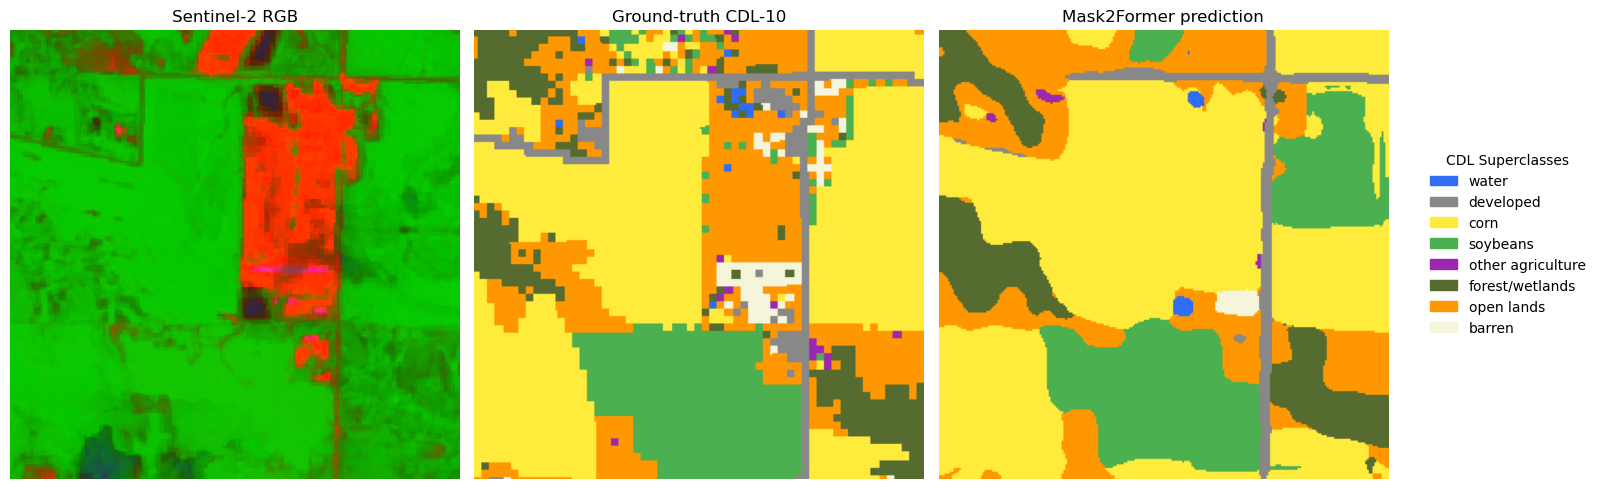

In [83]:
import matplotlib.patches as mpatches

# Run model + extract
batch = next(iter(DataLoader(dataset_test, batch_size=1, shuffle=True)))
img = batch["pixel_values"][0]
gt  = batch["labels"][0].numpy()
pred = mf_predict(img)

# Convert to RGB for display
gt_rgb   = vec_translate(gt, id2color)
pred_rgb = vec_translate(pred, id2color)

# Find unique classes shown in either image
present_ids = sorted(set(np.unique(gt)) | set(np.unique(pred)))

# Generate legend handles only for classes present
legend_patches = [
    mpatches.Patch(color=np.array(id2color[i])/255.0, label=id2label[i])
    for i in present_ids
]

# Plot
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(img.permute(1,2,0));  ax[0].set_title("Sentinel-2 RGB")
ax[1].imshow(gt_rgb);              ax[1].set_title("Ground-truth CDL-10")
ax[2].imshow(pred_rgb);            ax[2].set_title("Mask2Former prediction")

# Turn off axis ticks
for a in ax: a.axis("off")

# Add legend to far right
fig.legend(handles=legend_patches, loc="center right", title="CDL Superclasses", frameon=False)
plt.tight_layout(rect=[0, 0, 0.88, 1])  # leave space on right
plt.show()


In [84]:
def bounds_to_img(user_email, udf_str, bounds, kw_dict, png_req=False, dim=3):
    """
    Calls your UDF and returns the first `dim` bands as an H×W×dim uint8 array.
    Works whether `xarr.image` comes back as CHW or HWC.
    """
    # 1) Inject bbox into the params
    kws = {**{'west':bounds[0], 'south':bounds[1],
             'east':bounds[2],  'north':bounds[3]},
           **kw_dict}

    # 2) Run the UDF
    xarr = fused.run(user_email, udf_str, **kws)

    # 3) Grab the raw array
    try:
        arr = np.array(xarr.image, dtype='uint8')
    except Exception:
        arr = np.array(xarr[0].image, dtype='uint8')

    # 4) Identify layout & slice channels
    if arr.ndim != 3:
        raise ValueError(f"Expected 3-D image, got shape {arr.shape}")

    H, W, C = None, None, None
    # Case A: CHW
    if arr.shape[0] in (3, 4) and arr.shape[1] > 10 and arr.shape[2] > 10:
        # channels on axis=0
        C, H, W = arr.shape
        chw = arr[:dim]                 # (dim, H, W)
        hwc = np.transpose(chw, (1,2,0))  # (H, W, dim)
    # Case B: HWC
    elif arr.shape[-1] in (3, 4):
        # channels on axis=2
        H, W, C = arr.shape
        hwc = arr[..., :dim]            # (H, W, dim)
    else:
        raise ValueError(f"Unrecognized image layout {arr.shape}")

    # 5) Return as PIL or numpy
    if png_req:
        return Img.fromarray(hwc[..., :3])  # only RGB
    return hwc


In [85]:
recipe ={'agg_type': 'percentile', 'brightness': 1.2, 'gamma': 0.55, 'layer_name': 'Sentinel-2 Composer', 'month_window': 0, 'nd_max': 0.35, 'nd_min': -0.15, 'ordering_type': 'Cloud ordered', 'pB': 'snow', 'pG': 'msavi', 'pR': 'new_built', 'percentile': 10, 'qa': False, 'saturation': 1.2, 'temp_max': 310, 'temp_min': 293, 'threshold': 0.35, 'time_slice_count': None, 'zoom': 14}
recipe

{'agg_type': 'percentile',
 'brightness': 1.2,
 'gamma': 0.55,
 'layer_name': 'Sentinel-2 Composer',
 'month_window': 0,
 'nd_max': 0.35,
 'nd_min': -0.15,
 'ordering_type': 'Cloud ordered',
 'pB': 'snow',
 'pG': 'msavi',
 'pR': 'new_built',
 'percentile': 10,
 'qa': False,
 'saturation': 1.2,
 'temp_max': 310,
 'temp_min': 293,
 'threshold': 0.35,
 'time_slice_count': None,
 'zoom': 14}

In [86]:
%%time
bbox_holdout = [-96.56293,43.280441,-96.46407,43.335954]   #your Iowa extent here

holdout_s2_dict = dict(
    year=2024, 
    month="06", 
    month_window=0,
    time_slice_count=7, 
    ordering="cloud_ordered",
    agg_type="percentile", 
    percentile=10, 
    qa=False,
    # ─ Cropland switches ─
    cdl_alpha=True, 
    cdl_year=2024,
    cdl_colored=False, 
    cdl_as_mask=False, 
    crop_type="",
    zoom=14, 
    gamma=0.55,
    brightness=1.2,
    saturation_factor=1.2,
    r_mult = 0.8,
    g_mult = 1.4,
    b_mult = 1.05,
    pR="new_built", 
    pG="msavi", 
    pB="snow",  # ← compositing logic
    nd_max=0.35,
     nd_min=-0.15,
)

img_rgb = bounds_to_img(
    user_email=my_fused_email,
    udf_str="S2_composer_bbox",   # ← your UDF string here
    bounds=bbox_holdout,
    kw_dict=holdout_s2_dict,
    png_req=False,  # or True if you want a PIL.Image
    dim = 4
)


CPU times: user 33.2 ms, sys: 101 ms, total: 134 ms
Wall time: 29 s


(-0.5, 1100.5, 849.5, -0.5)

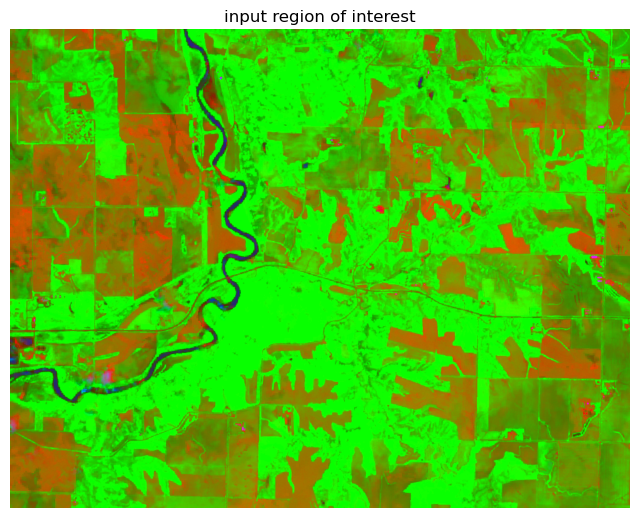

In [87]:
plt.figure(figsize=(8,8)); 
plt.title('input region of interest')
plt.imshow(img_rgb[:,:,:3])
plt.axis('off')

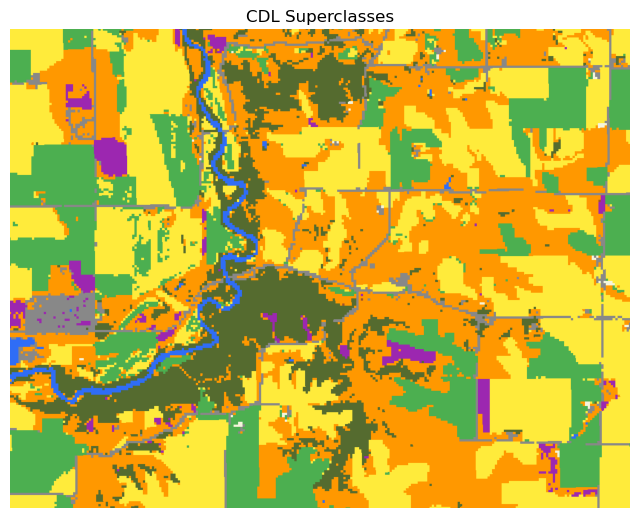

In [88]:
cdl_super = np.vectorize(cdl_simple_map.get)(img_rgb[:,:,3]).astype(int)
cdl_rgb   = vec_translate(cdl_super, id2color)
plt.figure(figsize=(8,8))
plt.imshow(cdl_rgb)
plt.axis("off")
plt.title("CDL Superclasses")
plt.show()

CPU times: user 17.3 s, sys: 13.4 s, total: 30.7 s
Wall time: 1min 59s


(-0.5, 959.5, 719.5, -0.5)

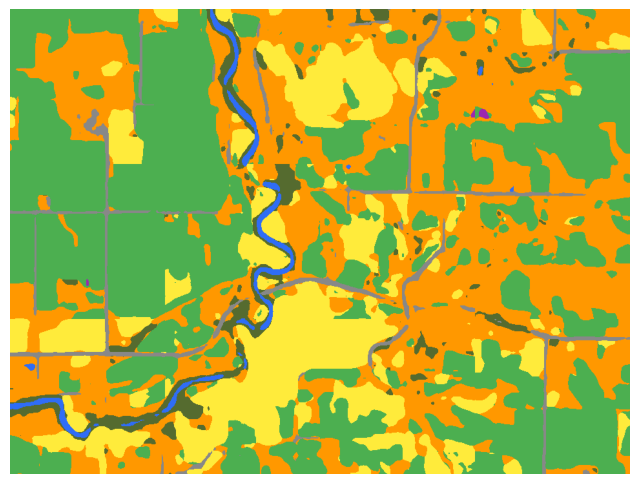

In [89]:
%%time
roi_pred = tile_and_predict_with_buffer(img_rgb[:,:,:3], d_inner=240, d_outer=620)
plt.figure(figsize=(8,8)); 
plt.imshow(vec_translate(roi_pred, id2color)); 
plt.title("Predicted Superclasses")
plt.axis('off')

In [91]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib import patches

def plot_super_iou(
        gt_arr, pred_arr,
        id2color, id2label,
        figsize=(8,8), n_cols=3,
        tiny=10.0         # side-length of the “missing” outline square
    ):
    # ─── crop to overlapping extent ──────────────────────────────────────
    H = min(gt_arr.shape[0], pred_arr.shape[0])
    W = min(gt_arr.shape[1], pred_arr.shape[1])
    gt, pr = gt_arr[:H,:W], pred_arr[:H,:W]

    codes   = sorted(set(np.unique(gt)).union(np.unique(pr)))
    n_rows  = int(np.ceil(len(codes)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=figsize, facecolor="black")
    axes = axes.ravel()

    for k, c in enumerate(codes):
        ax = axes[k]; ax.set_facecolor("black"); ax.axis("off")

        gmask, pmask = gt==c, pr==c
        ng, npix     = gmask.sum(), pmask.sum()
        inter        = np.logical_and(gmask, pmask).sum()
        union        = ng + npix - inter
        iou          = 100.*inter/union if union else 0.

        col = np.array(id2color[c])/255.
        sf  = 10.0
        sg  = np.sqrt(ng*sf)   if ng   else 0.0
        sp  = np.sqrt(npix*sf) if npix else 0.0
        so  = np.sqrt(inter*sf) if inter else 0.0

        # filled squares
        if ng:
            ax.add_patch(patches.Rectangle((0,0), sg, sg,
                                           fc=col, alpha=.5, lw=1))
        if npix:
            dx = sg - so; dy = dx
            ax.add_patch(patches.Rectangle((dx,dy), sp, sp,
                                           fc=col, alpha=.5, lw=1))

        # outline cues
        if ng and not npix:   # ML missing
            ax.add_patch(patches.Rectangle((sg, sg), tiny, tiny,
                                           fc="none", ec=col, lw=1,
                                           clip_on=False))
        if npix and not ng:   # GT missing
            ax.add_patch(patches.Rectangle((-tiny, -tiny), tiny, tiny,
                                           fc="none", ec=col, lw=1,
                                           clip_on=False))

        # tags
        if ng:
            ax.text(0,0,"GT",va="bottom",fontsize=8,color="w")
        if npix:
            ax.text((sg-so)+sp, (sg-so)+sp, "ML",
                    ha="right",va="top",fontsize=8,color="w")

        # IoU %
        ax.text(.5,.45,f"{iou:4.1f}%",ha="center",
                transform=ax.transAxes, color="w", weight="bold")

        # pixel-count tuple  (GT, ML)
        ax.text(.98, .02, f"({ng}, {npix})",      # lower-right
                ha="right", va="bottom",
                transform=ax.transAxes,
                fontsize=8, color="w")

        # class label
        ax.text(.5,-.10,id2label[c], ha="center",
                transform=ax.transAxes, color="w", fontsize=9)

        # limits
        xmax = max(sg, (sg-so)+sp) + tiny
        ax.set_xlim(-tiny, xmax)
        ax.set_ylim(-tiny, xmax)
        ax.set_aspect("equal")

    # blank unused cells
    for j in range(len(codes), n_rows*n_cols):
        axes[j].axis("off")

    plt.suptitle("Class-wise IoU (CDL super-classes)", color="white", fontsize=16)
    plt.tight_layout()


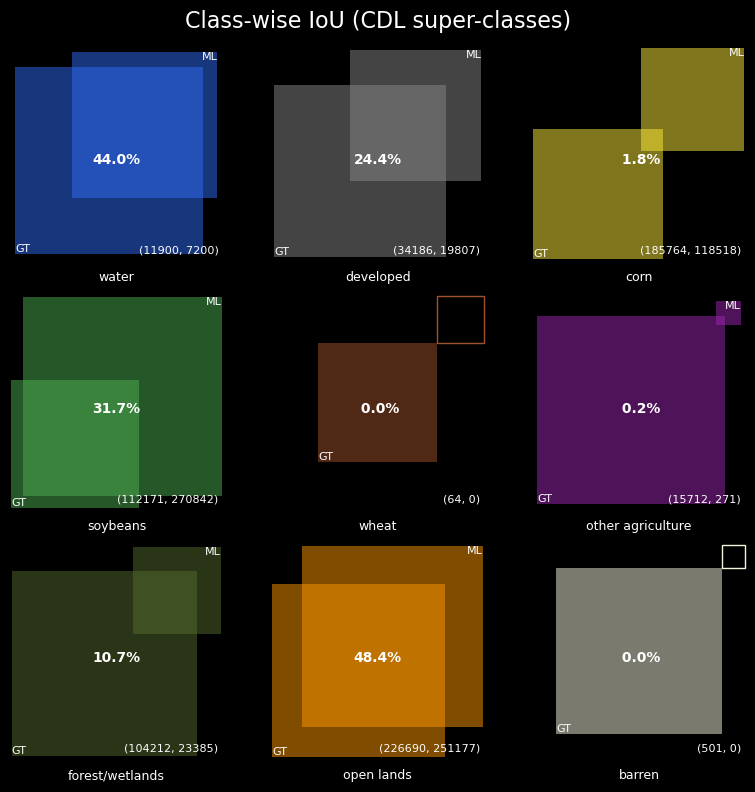

In [92]:
plot_super_iou(cdl_super, roi_pred, id2color, id2label)
